# Actividad:SVM (Breast Cancer)



**Objetivo:** aplicar SVM a un conjunto de datos real (Breast Cancer Wisconsin) y comparar:
- **SVM lineal** vs **SVM con kernel RBF**
- Ver los efectos del **escalado**
- Evaluación con métricas y matrices de confusión
- Breast Cancer Wiscosin está incluido en sklearn. Puedes encontrarlo [aquí](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)


**SVC** es la clase que:

- se instancia para crear el modelo (svm_lineal, svm_rbf),

- se entrena con fit,

- se usa para predecir con predict.

In [85]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Carga y estudio del conjunto de datos

El conjunto **Breast Cancer Wisconsin** es un dataset real de clasificación binaria. El objetivo es predecir si un tumor es **maligno** o **benigno** a partir de características numéricas.

En esta celda:
- cargaremos los datos,
- revisaremos dimensiones,
- comprobaremos la distribución de clases.

| Variable | Qué representa                         |
| -------- | -------------------------------------- |
| `data`   | Dataset completo (datos + metadatos)   |
| `X`      | Variables de entrada (características) |
| `y`      | Variable objetivo (clase)              |


In [86]:
df_cancer = load_breast_cancer(as_frame=True).frame

### Vista rápida de algunas características

Mostramos las 5 primeras filas para ver el tipo de datos.

In [87]:
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


df es un DataFrame de pandas que ya contiene las características (X).

'target' es el nombre de la nueva columna que se va a crear.

y es el vector de etiquetas (la clase de cada muestra).
tras ejecutar la siguiente celda tendremos:   
columnas → características + target

filas → cada muestra con:

sus variables

su clase (0 o 1)

In [88]:
df_cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

### Distribución de clases

En problemas de clasificación es importante verificar si hay **desbalanceo**.
El desbalanceo indica si hay equilibrio entre los datos que hay correspondientes a cada clase
Estudiando la gráfica comprobamos si hay un número parecido de casos en cada categoría

In [89]:
df_cancer.corr(numeric_only=True)['target'].sort_values(ascending=False)[1:]

smoothness error           0.067016
mean fractal dimension     0.012838
texture error              0.008303
symmetry error             0.006522
fractal dimension error   -0.077972
concavity error           -0.253730
compactness error         -0.292999
worst fractal dimension   -0.323872
mean symmetry             -0.330499
mean smoothness           -0.358560
concave points error      -0.408042
mean texture              -0.415185
worst symmetry            -0.416294
worst smoothness          -0.421465
worst texture             -0.456903
area error                -0.548236
perimeter error           -0.556141
radius error              -0.567134
worst compactness         -0.590998
mean compactness          -0.596534
worst concavity           -0.659610
mean concavity            -0.696360
mean area                 -0.708984
mean radius               -0.730029
worst area                -0.733825
mean perimeter            -0.742636
worst radius              -0.776454
mean concave points       -0

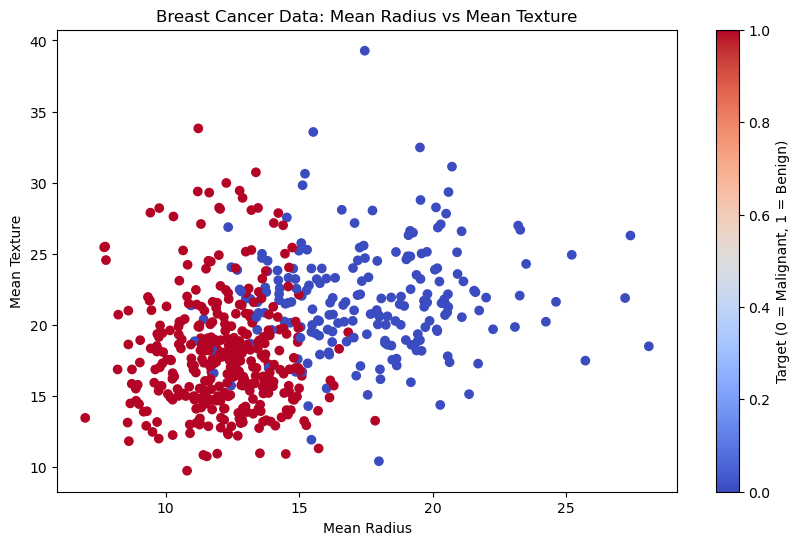

In [90]:
plt.figure(figsize=(10,6))
plt.scatter(df_cancer['mean radius'], df_cancer['mean texture'], c=df_cancer['target'], cmap='coolwarm')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Breast Cancer Data: Mean Radius vs Mean Texture')
plt.colorbar(label='Target (0 = Malignant, 1 = Benign)')
plt.show()

## 2. Preparación de datos: Train/Test y escalado

Dividimos en entrenamiento y prueba usando `stratify=y` para mantener la proporción de clases. Después, aplicaremos **StandardScaler** (media 0, desviación 1).=> estandarizamos (aunque coloquialmente podeos decir normalizamos)

In [91]:
X = df_cancer.drop(['target'],axis=1)
y = df_cancer['target'].to_frame()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Entrenamiento y evaluación de modelos SVM

Entrenaremos dos modelos:
- **SVM lineal** 
- **SVM RBF** (no lineal)

Evaluaremos con:
- accuracy -> exhaustividad
- matriz de confusión
- classification report -> Muestra varias métricas: Precision, Recall(De todos los casos reales de esa clase, ¿cuántos ha detectado el modelo?),
- F1-score


### 3.1 SVM con kernel lineal

Usamos **C=1** como valor base (es un buen inicio).

In [92]:
svm_lineal = SVC(kernel="linear", C=1.0, random_state=42)
svm_lineal.fit(X_train_scaled, y_train)

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(kernel='linear', random_state=42)

### 3.2 SVM con kernel RBF

Probaremos un primer modelo con valores razonables de C y gamma. Después, probaremos más combinaciones

In [105]:
svm_rbf = SVC(kernel="rbf", C=5.0, gamma=0.01, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

/home/ciabd12/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SVC(C=5.0, gamma=0.01, random_state=42)

### 3.3 Ajuste manual básico

Probamos algunas combinaciones de **C** y **gamma** y guardamos la mejor según **accuracy** en test. 

In [106]:
pred_lineal = svm_lineal.predict(X_test_scaled)
pred_rbf = svm_rbf.predict(X_test_scaled)

print("=== SVM LINEAL ===")
print("Accuracy:", accuracy_score(y_test, pred_lineal)) #exactitud
print(confusion_matrix(y_test, pred_lineal))
print(classification_report(y_test, pred_lineal))

print("\n=== SVM RBF ===")
print("Accuracy:", accuracy_score(y_test, pred_rbf))
print(confusion_matrix(y_test, pred_rbf))
print(classification_report(y_test, pred_rbf))

=== SVM LINEAL ===
Accuracy: 0.986013986013986
[[52  1]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143


=== SVM RBF ===
Accuracy: 0.986013986013986
[[52  1]
 [ 1 89]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



## 4. Resumen

Responde brevemente:
1. ¿Qué modelo ha rendido mejor, lineal o RBF?
2. ¿Cómo cambia el rendimiento al variar C y gamma?
3. ¿Por qué es importante el escalado en SVM?

> *Sugerencia:* apóyate en la matriz de confusión y en el classification report.